In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

/home/user/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Set professional plotting style
plt.style.use('fivethirtyeight')
sns.set_palette("viridis")

# 1. Load the Master Feature Table
df = pd.read_csv('/home/user/Suraj/Work/SaaS/Data/churn_data.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df['churn_flag'].value_counts())


Dataset loaded: 2000 rows, 11 columns
churn_flag
0    1786
1     214
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account_id              2000 non-null   object 
 1   plan_tier               2000 non-null   object 
 2   industry                2000 non-null   object 
 3   referral_source         2000 non-null   object 
 4   total_tickets           2000 non-null   int64  
 5   avg_csat                2000 non-null   float64
 6   avg_res_time            2000 non-null   float64
 7   has_sso                 2000 non-null   int64  
 8   has_webhook             2000 non-null   int64  
 9   active_days_last_month  2000 non-null   int64  
 10  churn_flag              2000 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 172.0+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
account_labels = df['account_id']

In [6]:
df_model = df.drop('account_id',axis = 1)

In [7]:
#  One-Hot Encoding (The Correct Way for Logistic Regression)
#  drop_first=True to avoid redundant data (Dummy Variable Trap)
df_encoded = pd.get_dummies(df_model, 
                            columns=['plan_tier', 'industry', 'referral_source'], 
                            drop_first=True)

In [8]:
df_encoded

,total_tickets,avg_csat,avg_res_time,has_sso,has_webhook,active_days_last_month,churn_flag,plan_tier_Enterprise,plan_tier_Pro,industry_E-commerce,...,industry_Media,industry_Real Estate,industry_SaaS,referral_source_Direct,referral_source_Events,referral_source_LinkedIn,referral_source_Organic Search,referral_source_Paid Search,referral_source_Partnership,referral_source_Referral
0,12,4.0,70.0,1,1,7,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,4,4.0,96.0,0,0,5,0,False,False,False,...,False,False,True,False,False,True,False,False,False,False
2,16,3.0,80.0,1,0,10,0,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,6,3.0,89.0,0,1,10,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3,5.0,44.0,0,0,4,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,3.0,0.0,0,0,0,0,True,False,False,...,False,True,False,False,False,False,False,False,False,True
1996,0,3.0,0.0,0,0,0,0,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1997,0,3.0,0.0,0,0,0,0,False,True,False,...,False,True,False,False,False,True,False,False,False,False
1998,0,3.0,0.0,0,0,0,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [9]:
X = df_encoded.drop('churn_flag',axis=1)
y = df_encoded['churn_flag']

In [10]:
# 1. Split data (80% Train, 20% Test)
# used stratify=y to ensure churners are balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# 2. Scaled features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [11]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probability of churn

print("Model Training Complete.")

Model Training Complete.


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       357
           1       0.70      0.98      0.82        43

    accuracy                           0.95       400
   macro avg       0.85      0.96      0.89       400
weighted avg       0.97      0.95      0.96       400



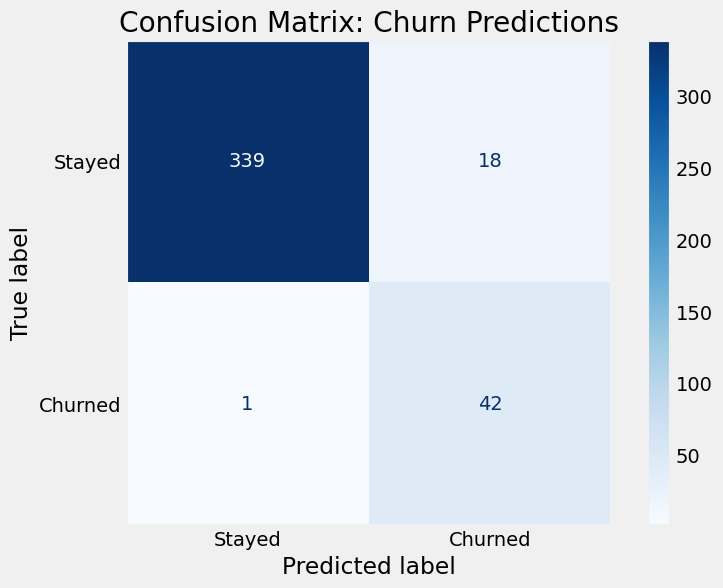

In [12]:
# the classification report 
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, 
                                      display_labels=['Stayed', 'Churned'], 
                                      cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Churn Predictions')
plt.grid(False)
plt.show()

Model expects 24 features.
X variable has 24 features.


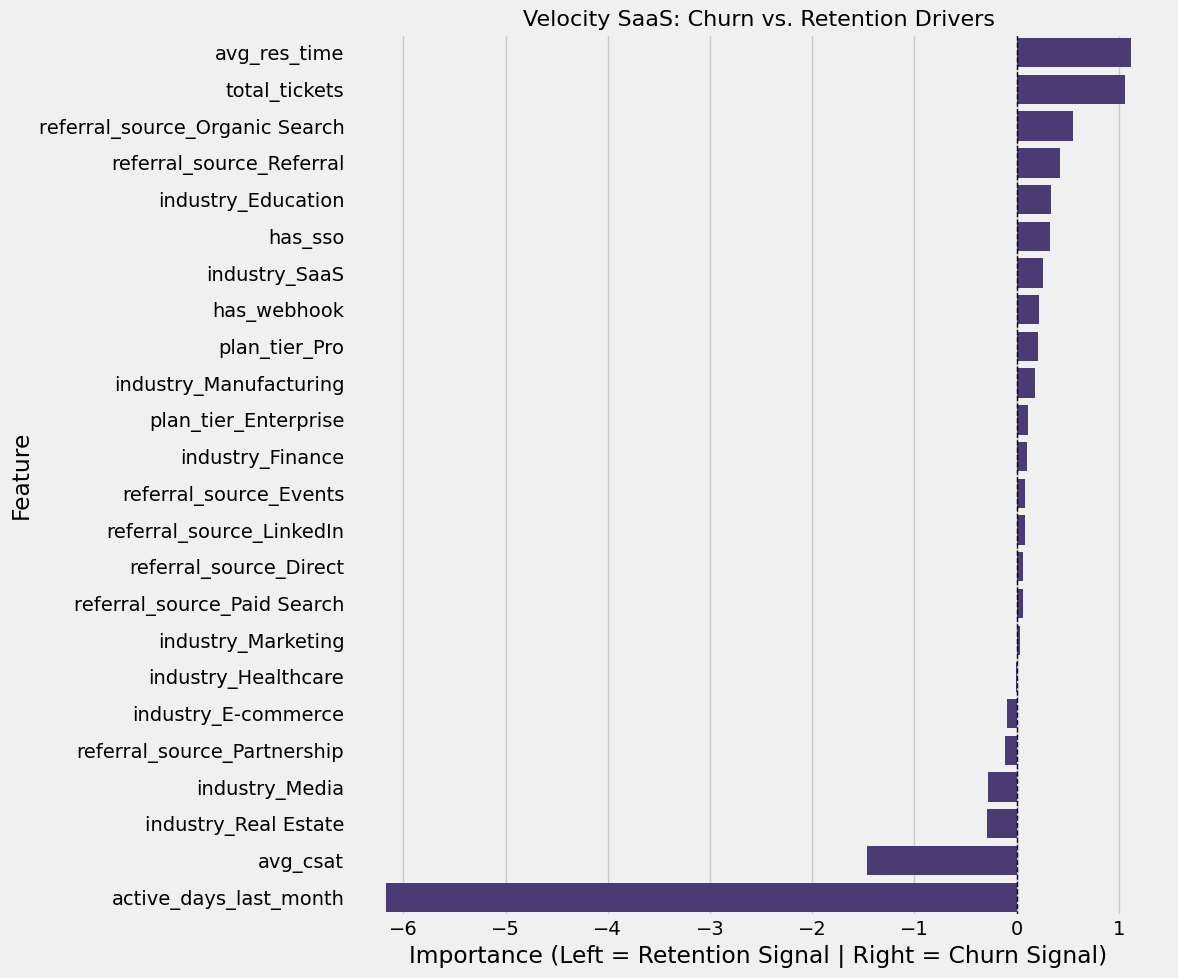

In [13]:
# 1. Check lengths
coef_len = len(model.coef_[0])
feature_len = len(X.columns)

print(f"Model expects {coef_len} features.")
print(f"X variable has {feature_len} features.")

# 2. If they don't match, we take the columns used during training
if coef_len != feature_len:
    print("⚠️ Mismatch detected! Using columns from X_train...")
    feature_names = X_train.columns
else:
    feature_names = X.columns

# 3. Create the DataFrame safely
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.coef_[0]
})

# 4. Sort and Plot
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Velocity SaaS: Churn vs. Retention Drivers', fontsize=16)
plt.xlabel('Importance (Left = Retention Signal | Right = Churn Signal)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()